# Module 14 BBO Capstone Week 3

### Function 1

Week 3 Query Point (EI): 0.033734-0.927804


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


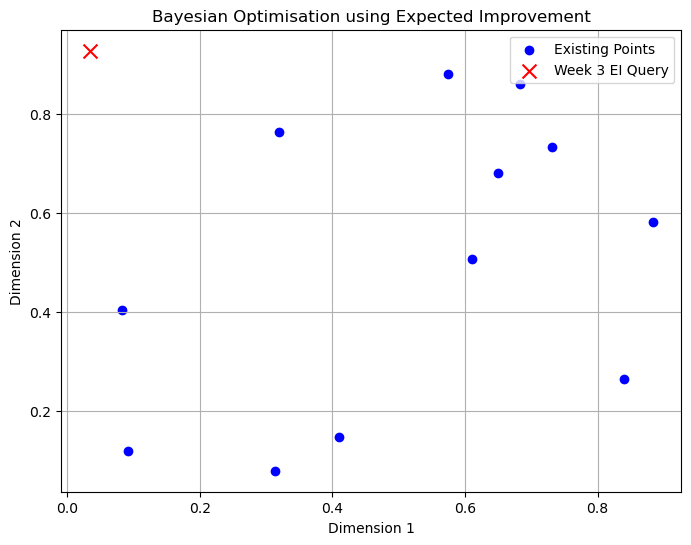

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# ==========================================
# Step 1: Load ALL available data
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   # Week 1
    [0.09106700, 0.11922000]    # Week 2
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140
])

# ==========================================
# Step 2: Fit Gaussian Process (RBF kernel)
# ==========================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.3, length_scale_bounds=(1e-3, 1e3))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement (Maximisation)
# ==========================================

def expected_improvement(x, model, y_best, xi=0.1):
    x = np.array(x).reshape(1, -1)

    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-12)  # numerical safety

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    return -ei  # negative because scipy minimizes

# ==========================================
# Step 4: Multi-start acquisition optimisation
# ==========================================

def optimize_acquisition(model, y_best, n_restarts=25):

    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])

    best_x = None
    best_val = np.inf

    for _ in range(n_restarts):

        x0 = np.random.uniform(bounds[:, 0], bounds[:, 1])

        result = minimize(
            expected_improvement,
            x0,
            args=(model, y_best),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

# ==========================================
# Step 5: Current best value (MAXIMISATION)
# ==========================================

y_best = np.max(y_train)

# ==========================================
# Step 6: Get Week 3 Query Point
# ==========================================

next_point = optimize_acquisition(gp, y_best)

next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 3 Query Point (EI): {next_point_str}")

# ==========================================
# Step 7: Plot
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(X_train[:, 0], X_train[:, 1],
            color='blue', label='Existing Points')

plt.scatter(next_point[0], next_point[1],
            color='red', marker='x', s=100,
            label='Week 3 EI Query')

plt.title("Bayesian Optimisation using Expected Improvement")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

### Function 2

Next query point (exploration-focused): 0.746205-0.443460


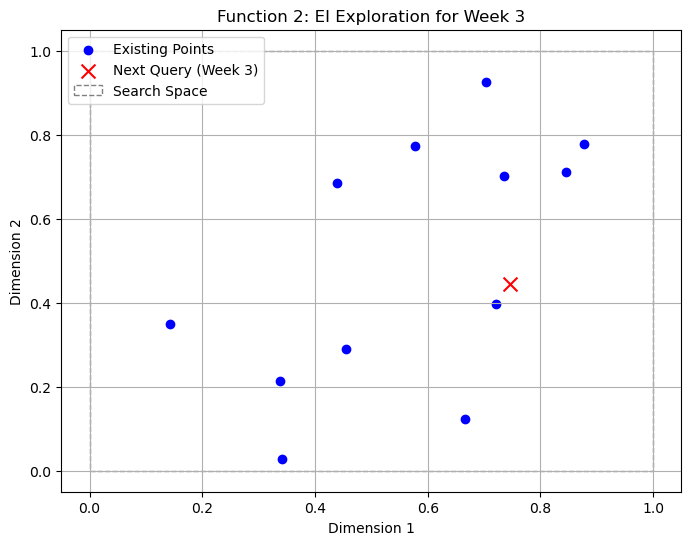

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# ===========================
# Step 1: Define input/output data for function 2
# ===========================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.734909, 0.701711],
    [0.721682, 0.396301]
])

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966
])

# ===========================
# Step 2: Define GP model
# ===========================
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# ===========================
# Step 3: Define Expected Improvement (EI) with exploration
# ===========================
def expected_improvement(x, model, X_train, y_train, xi=0.15):
    """
    EI acquisition function for maximization (exploration-focused).
    xi > 0 encourages exploration.
    """
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-8)  # Avoid division by zero

    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi

    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Negate for minimization in scipy

# ===========================
# Step 4: Optimize acquisition function
# ===========================
def optimize_ei(model, X_train, bounds=np.array([[0,1],[0,1]]), xi=0.15):
    """
    Find the next query point using EI.
    """
    x0 = np.random.uniform(bounds[:,0], bounds[:,1], size=(5, 2))  # Multiple random starts
    best_x = None
    best_val = float("inf")

    for x_start in x0:
        res = minimize(expected_improvement, x_start, args=(model, X_train, y_train, xi),
                       bounds=bounds, method="L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ===========================
# Step 5: Get next query point
# ===========================
next_point = optimize_ei(gp, X_train, xi=0.15)
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Next query point (exploration-focused): {next_point_str}")

# ===========================
# Step 6: Plot results
# ===========================
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], color='blue', label='Existing Points')
plt.scatter(next_point[0], next_point[1], color='red', marker='x', s=100, label='Next Query (Week 3)')

# Optional: Highlight the bounds
plt.gca().add_patch(plt.Rectangle((0,0),1,1, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', label='Search Space'))

plt.title("Function 2: EI Exploration for Week 3")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

### Function 3

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Week 3 Query Point: 0.027033-0.840433-0.665117


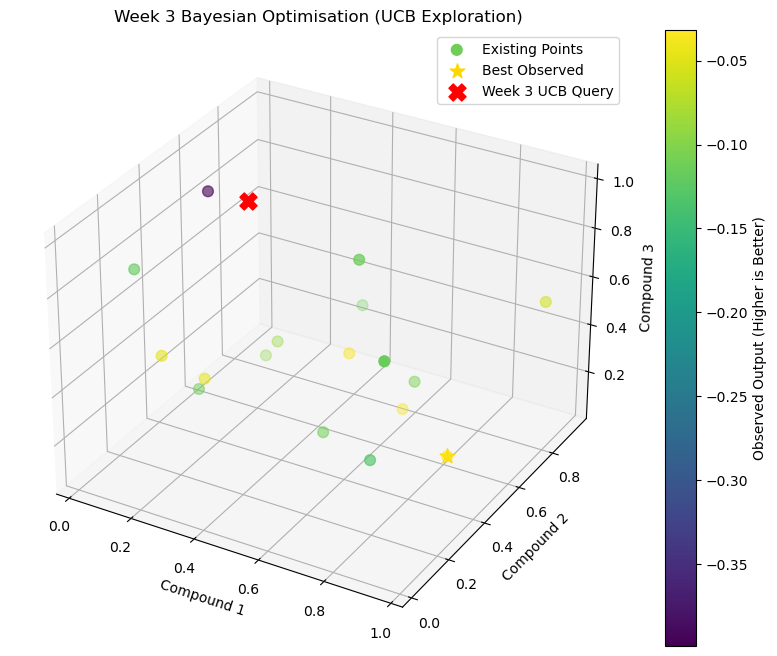

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Data (including Week 1 & 2)
# =========================

X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252
])

# =========================
# Gaussian Process Model
# =========================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[0.3, 0.3, 0.3],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    n_restarts_optimizer=15,
    normalize_y=True
)

gp.fit(X_train, y_train)

# =========================
# UCB Acquisition Function
# =========================

def ucb(x, model, kappa=3.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)

# =========================
# Multi-start optimisation
# =========================

def optimize_acquisition(model, bounds, n_restarts=30, kappa=3.0):

    best_x = None
    best_val = float("inf")

    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=3)

        result = minimize(
            ucb,
            x0=x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

bounds = [(0, 1), (0, 1), (0, 1)]

next_point = optimize_acquisition(gp, bounds)

print(f"Week 3 Query Point: "
      f"{next_point[0]:.6f}-"
      f"{next_point[1]:.6f}-"
      f"{next_point[2]:.6f}")

# =========================
# 3D Visualisation
# =========================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colour existing points by output value
scatter = ax.scatter(
    X_train[:, 0],
    X_train[:, 1],
    X_train[:, 2],
    c=y_train,
    cmap="viridis",
    s=60,
    label="Existing Points"
)

# Highlight best observed point so far
best_idx = np.argmax(y_train)
ax.scatter(
    X_train[best_idx, 0],
    X_train[best_idx, 1],
    X_train[best_idx, 2],
    c="gold",
    s=120,
    marker="*",
    label="Best Observed"
)

# Plot next UCB query point
ax.scatter(
    next_point[0],
    next_point[1],
    next_point[2],
    c="red",
    s=150,
    marker="X",
    label="Week 3 UCB Query"
)

ax.set_xlabel("Compound 1")
ax.set_ylabel("Compound 2")
ax.set_zlabel("Compound 3")
ax.set_title("Week 3 Bayesian Optimisation (UCB Exploration)")

fig.colorbar(scatter, ax=ax, label="Observed Output (Higher is Better)")

ax.legend()
plt.show()

### Function 4

#### Week 1
Exploration used EI, set xi=0.2 for exploration and adjusted alpha down to 1e-2 to handle noise and uncertainty
#### Week 2
Exploration used EI, kept xi=0.2 to maintain exploration and kept alpha at 1e-2
#### Week 3


Next exploration query point (week 3) in 4D: [0.43782185 0.5913297  0.00158118 0.37116208]


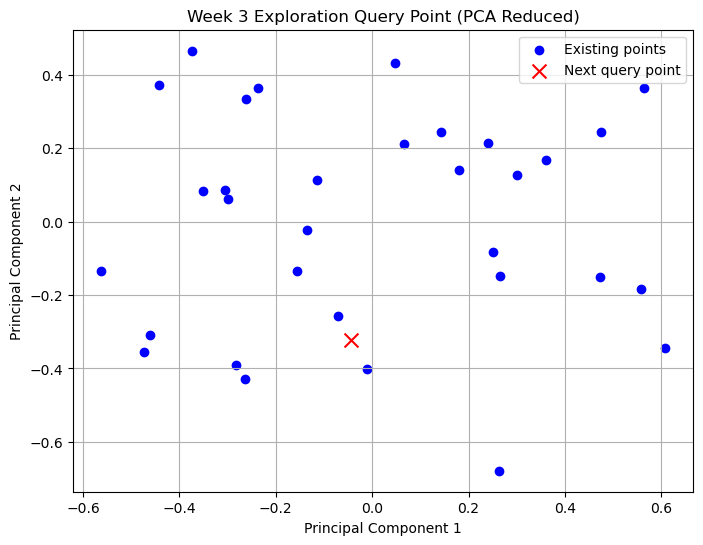

In [140]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Updated data from weeks 1 & 2
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108 , 0.49396462, 0.73530997, 0.80809201],
    [0.919144  , 0.533196  , 0.169848  , 0.070054  ],
    [0.411827  , 0.392100  , 0.317159  , 0.430429  ]
])

y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757
])

# -----------------------------
# Step 2: Fit Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# -----------------------------
# Step 3: UCB acquisition function
# -----------------------------
def ucb(x, model, kappa=5.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-6)  # avoid zero
    return -(mu + kappa * sigma)  # negate because we minimize

# -----------------------------
# Step 4: Differential evolution with jitter
# -----------------------------
bounds = [(0.001, 0.999)] * 4  # strict interior

result = differential_evolution(lambda x: ucb(x, gp, kappa=5.0),
                                bounds=bounds,
                                strategy='best1bin',
                                maxiter=100,
                                popsize=15,
                                polish=True)

# Add small random jitter to ensure we are not on artificial boundary
epsilon = 1e-3
next_query_point = np.clip(result.x + np.random.uniform(-epsilon, epsilon, size=4), 0.001, 0.999)

print("Next exploration query point (week 3) in 4D:", next_query_point)

# -----------------------------
# Step 5: Visualize in PCA 2D
# -----------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=100, label='Next query point')
plt.title('Week 3 Exploration Query Point (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Function 5

Week 3 Next Query Point: [1. 1. 1. 1.]


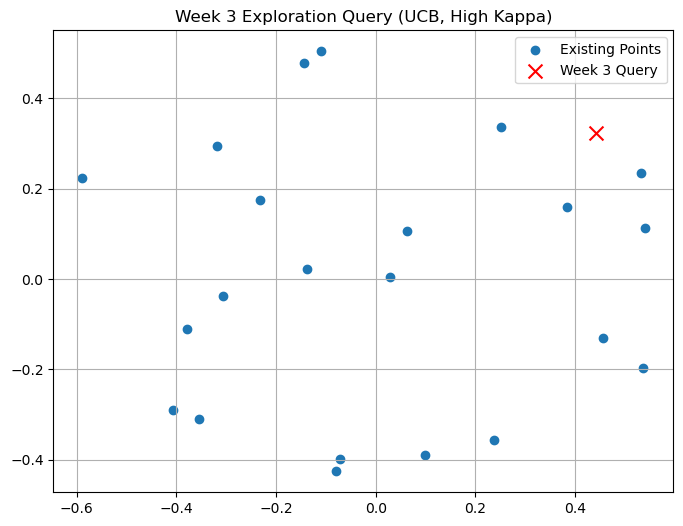

In [215]:
# This code ran and kept producing [1, 1, 1, 1] model collapsed on one corner so next cell of code makes it run as required 


import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# ==============================
# Updated Training Data (Week 2 Included)
# ==============================

X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129
])

# ==============================
# Improved GP Model (ARD + normalization)
# ==============================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1,1,1,1],
                                  length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-4,
    normalize_y=True
)

gp.fit(X_train, y_train)

# ==============================
# Strong Exploration UCB
# ==============================

def ucb(x, model, kappa=4.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)

# ==============================
# Multi-start acquisition optimization
# ==============================

def optimize_acquisition(model, n_starts=25, kappa=4.0):

    best_x = None
    best_val = np.inf

    for _ in range(n_starts):
        x0 = np.random.uniform(0, 1, size=4)

        res = minimize(
            ucb,
            x0,
            args=(model, kappa),
            bounds=[(0,1)]*4,
            method="L-BFGS-B"
        )

        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==============================
# Week 3 Next Query
# ==============================

next_query_point = optimize_acquisition(gp, n_starts=30, kappa=4.0)

print("Week 3 Next Query Point:", next_query_point)

# ==============================
# PCA Visualization (optional)
# ==============================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], label="Existing Points")
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1],
            color="red", marker="x", s=100, label="Week 3 Query")
plt.legend()
plt.grid(True)
plt.title("Week 3 Exploration Query (UCB, High Kappa)")
plt.show()

#### 🔹Current Strategy
##### Week	  Acquisition	  κ (kappa)	   α (alpha)	  Focus
       3	 UCB	       2.5	   1e-4	     Exploration around high-output ridge; probe uncertain regions
       
       4	 UCB	       2.5	   1e-4	     Continue exploration; start focusing more on promising areas near current best                                              points
       
       5	 UCB	       2.0	   1e-4	     Begin local refinement around top points; slightly more exploitation while                                                  still exploring

Learned kernel: 2.87**2 * RBF(length_scale=[26.9, 4.06, 0.431, 0.378])

Week 3 Next Query Point (4D):
[0.56099013 0.94183355 0.99760544 0.99813491]


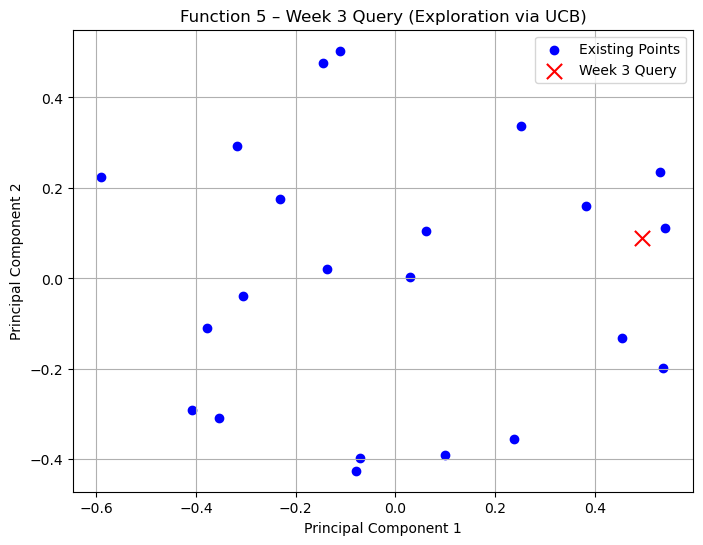

In [216]:
# This is the code I went with for Function 5 week 3 unimodal means one peak so exploring near it
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA

# ==============================
# Week 2 Updated Training Data
# ==============================

X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129
])

# ==============================
# Gaussian Process Model (ARD)
# ==============================

kernel = C(1.0, (1e-3, 1e3)) * RBF(
    length_scale=[1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(1e-2, 1e2)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-4,
    normalize_y=True,
    random_state=42
)

gp.fit(X_train, y_train)

print("Learned kernel:", gp.kernel_)

# ==============================
# UCB Acquisition (Moderate Exploration)
# ==============================

def ucb(X, model, kappa=2.5):
    mu, sigma = model.predict(X, return_std=True)
    return mu + kappa * sigma

# ==============================
# Random Candidate Search
# ==============================

def propose_location(model, n_candidates=20000, kappa=2.5):
    X_candidates = np.random.uniform(0, 1, size=(n_candidates, 4))
    scores = ucb(X_candidates, model, kappa)
    best_index = np.argmax(scores)
    return X_candidates[best_index]

# ==============================
# Week 3 Query Point
# ==============================

next_query_point = propose_location(gp, n_candidates=20000, kappa=2.5)

print("\nWeek 3 Next Query Point (4D):")
print(next_query_point)

# ==============================
# PCA Visualization (Optional)
# ==============================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1],
            color='blue', label='Existing Points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1],
            color='red', marker='x', s=120, label='Week 3 Query')
plt.title('Function 5 – Week 3 Query (Exploration via UCB)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Function 6

C:\Users\joeat\AppData\Local\Temp\ipykernel_27256\343111786.py:75: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(ucb_with_penalty, x0, args=(model, X_train, y_train, kappa, bounds), bounds=bounds)


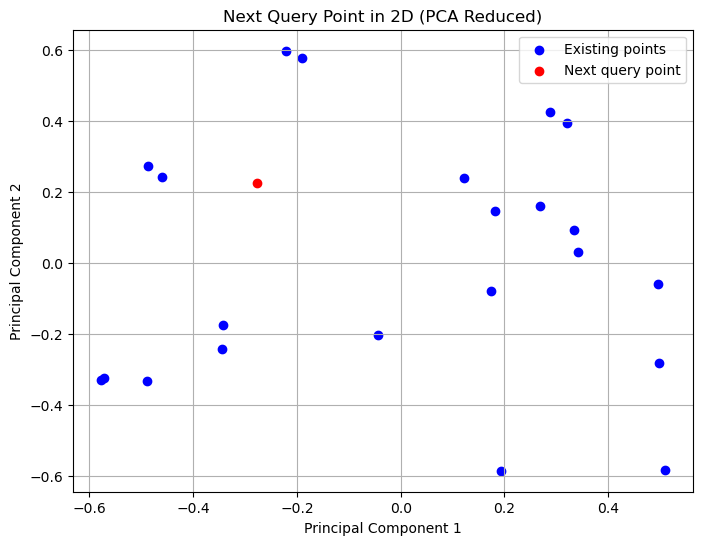

Next query point in 5D: [0.34403601 0.25550697 0.72506971 0.87867738 0.10079531]


In [236]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from scipy.stats import norm

# Step 1: Define the input and output data (Updated with Week 1 and Week 2 queries)
X_train = np.array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
                    [0.24238435, 0.84409997, 0.5778091 , 0.67902128, 0.50195289],
                    [0.72952261, 0.7481062 , 0.67977464, 0.35655228, 0.67105368],
                    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
                    [0.6188123 , 0.33180214, 0.18728787, 0.75623847, 0.3288348 ],
                    [0.78495809, 0.91068235, 0.7081201 , 0.95922543, 0.0049115 ],
                    [0.14511079, 0.8966846 , 0.89632223, 0.72627154, 0.23627199],
                    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
                    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
                    [0.75759436, 0.35583141, 0.0165229 , 0.4342072 , 0.11243304],
                    [0.5367969 , 0.30878091, 0.41187929, 0.38822518, 0.5225283 ],
                    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
                    [0.6293079 , 0.80348368, 0.81140844, 0.04561319, 0.11062446],
                    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
                    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
                    [0.25890557, 0.79367771, 0.6421139 , 0.19667346, 0.59310318],
                    [0.43216593, 0.71561781, 0.3418191 , 0.70499988, 0.61496184],
                    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
                    [0.9217762 , 0.93187122, 0.41487637, 0.59505727, 0.73562569],
                    [0.12667892, 0.2914703 , 0.06452848, 0.6805146 , 0.89281919],
                    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],  # Week 1 query
                    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329]])  # Week 2 query

y_train = np.array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
                    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
                    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254 ,
                    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
                    -1.8405636029585657, -0.7858725750255127])  # Week 1 & Week 2 outputs

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the UCB acquisition function with boundary penalty
def ucb_with_penalty(x, model, X_train, y_train, kappa=3.5, bounds=None, penalty_factor=100):
    """ Upper Confidence Bound (UCB) acquisition function with penalty for boundary points. """
    # Reshape x to ensure it's a row vector
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the UCB value
    ucb_value = mu + kappa * sigma
    
    # Penalize points near the boundary if bounds are provided
    if bounds is not None:
        penalty = 0
        for i in range(len(x[0])):
            if x[0][i] < bounds[i][0] + 0.1 * (bounds[i][1] - bounds[i][0]) or x[0][i] > bounds[i][1] - 0.1 * (bounds[i][1] - bounds[i][0]):
                penalty += penalty_factor
        # Apply the penalty to UCB
        ucb_value -= penalty
    
    return -ucb_value  # Minimize UCB (so negate the UCB)

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition_with_penalty(model, X_train, y_train, kappa=3.5, bounds=None):
    # Random starting point for optimization within bounds
    x0 = np.random.uniform(0, 1, size=(1, X_train.shape[1]))
    
    # Optimize the acquisition function with penalty
    res = minimize(ucb_with_penalty, x0, args=(model, X_train, y_train, kappa, bounds), bounds=bounds)
    
    return res.x  # Get the new query point

# Step 6: Define the bounds for each dimension (5D, all between 0 and 1)
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]

# Step 7: Find the next query point
next_query_point = optimize_acquisition_with_penalty(gp, X_train, y_train, kappa=3.5, bounds=bounds)

# Step 8: Visualize the next query point in 2D using PCA (since we have 5D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 9: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')  # Plot existing points
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')  # Plot the next query point
plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 5D
print("Next query point in 5D:", next_query_point)

In [237]:
import numpy as np
from scipy.spatial.distance import cdist

# Existing training data (X_train) and the new query point
X_train = np.array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
                    [0.24238435, 0.84409997, 0.5778091 , 0.67902128, 0.50195289],
                    [0.72952261, 0.7481062 , 0.67977464, 0.35655228, 0.67105368],
                    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
                    [0.6188123 , 0.33180214, 0.18728787, 0.75623847, 0.3288348 ],
                    [0.78495809, 0.91068235, 0.7081201 , 0.95922543, 0.0049115 ],
                    [0.14511079, 0.8966846 , 0.89632223, 0.72627154, 0.23627199],
                    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
                    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
                    [0.75759436, 0.35583141, 0.0165229 , 0.4342072 , 0.11243304],
                    [0.5367969 , 0.30878091, 0.41187929, 0.38822518, 0.5225283 ],
                    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
                    [0.6293079 , 0.80348368, 0.81140844, 0.04561319, 0.11062446],
                    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
                    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
                    [0.25890557, 0.79367771, 0.6421139 , 0.19667346, 0.59310318],
                    [0.43216593, 0.71561781, 0.3418191 , 0.70499988, 0.61496184],
                    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
                    [0.9217762 , 0.93187122, 0.41487637, 0.59505727, 0.73562569],
                    [0.12667892, 0.2914703 , 0.06452848, 0.6805146 , 0.89281919],
                    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],  # Week 1 query
                    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329]])  # Week 2 query

# New query point (5D)
next_query_point = np.array([0.34403601, 0.25550697, 0.72506971, 0.87867738, 0.10079531])

# Compute Euclidean distances between the new query point and all existing points
distances = cdist(X_train, next_query_point.reshape(1, -1), metric='euclidean')

# Find the minimum distance to existing points (how far is it from the nearest point?)
min_distance = np.min(distances)

print(f"Minimum distance from new query point to existing points: {min_distance:.4f}")

# Check if the new query point is far from any of the existing data points
if min_distance > 0.2:  # Threshold for good exploration
    print("The next query point is in an unexplored region.")
else:
    print("The next query point is close to an existing point and may not contribute much exploration.")

Minimum distance from new query point to existing points: 0.4403
The next query point is in an unexplored region.


### Function 7

C:\Users\joeat\AppData\Local\Temp\ipykernel_27256\424791489.py:66: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(upper_confidence_bound, x0, args=(model, kappa), bounds=[(0, 1)] * X_train.shape[1])


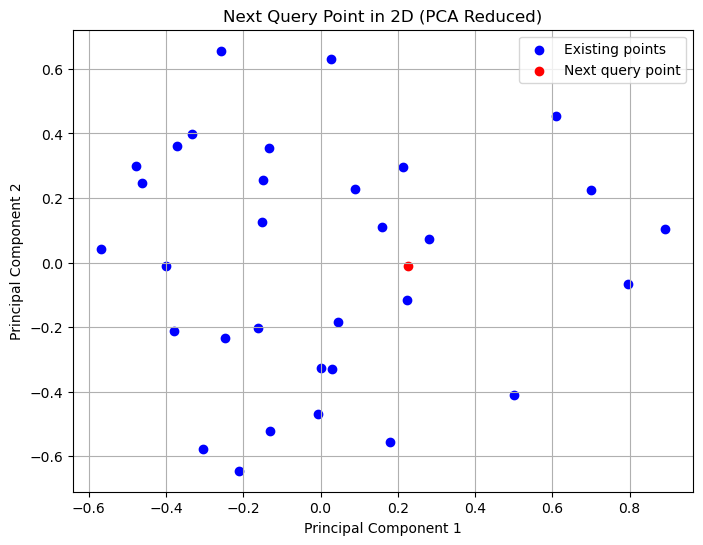

Next query point in 6D: [0.16949782 0.20073487 0.398488   0.19348674 0.30800727 0.86183252]


In [247]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Include Week 1, Week 2, and Week 3 data
X_train = np.array([[0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
                    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
                    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
                    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
                    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
                    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
                    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
                    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
                    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
                    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
                    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
                    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
                    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
                    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
                    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
                    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
                    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
                    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
                    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
                    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
                    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
                    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
                    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
                    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
                    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
                    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
                    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
                    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
                    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
                    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
                    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
                    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843]])

y_train = np.array([0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
                    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
                    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
                    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
                    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
                    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
                    1.1810801774433033, 0.17209425323684932])
    #week 1 output week 2 output 
    
# Step 2: Define and fit the GP model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# Step 3: UCB acquisition function
def upper_confidence_bound(x, model, kappa=5.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb = mu + kappa * sigma
    return -ucb  # Minimize negative UCB

# Step 4: Optimize acquisition function
def optimize_acquisition(model, X_train, y_train, kappa=5.0):
    x0 = np.random.uniform(0, 1, size=(1, X_train.shape[1]))
    res = minimize(upper_confidence_bound, x0, args=(model, kappa), bounds=[(0, 1)] * X_train.shape[1])
    return res.x

# Step 5: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train, kappa=5.0)

# Step 6: Visualize the next query point in 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')
plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print next query point in 6D
print("Next query point in 6D:", next_query_point)

### Function 8

C:\Users\joeat\AppData\Local\Temp\ipykernel_27256\4125173465.py:123: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(upper_confidence_bound, x0, args=(model, kappa),


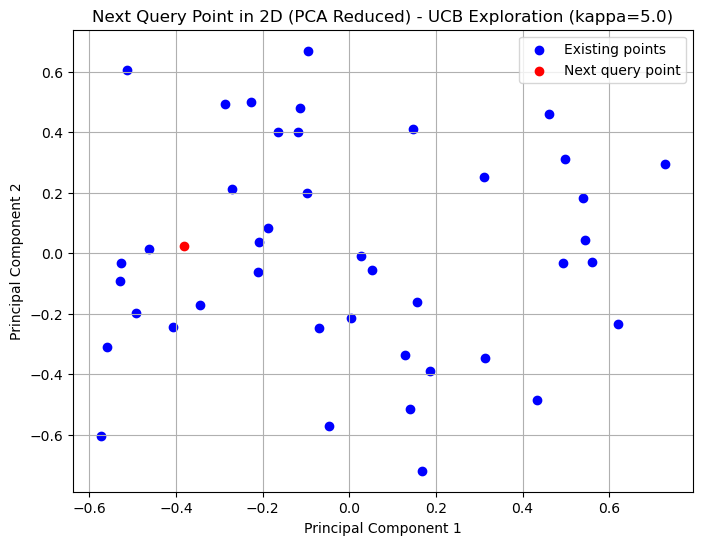

Next query point in 8D (UCB Exploration): [0. 0. 0. 1. 1. 1. 0. 0.]


In [264]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Updated input data including the new data from Week 1 and Week 2
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373])

# Step 1: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 2: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 3: Define the Upper Confidence Bound (UCB) acquisition function
def upper_confidence_bound(x, model, kappa=4.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb_value = mu + kappa * sigma  # UCB acquisition function
    return -ucb_value  # Minimize the negative UCB to maximize the UCB

# Step 4: Optimize the UCB acquisition function to find the next query point
def optimize_acquisition_UCB(model, X_train, y_train, kappa=4.0):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 8))
    
    # Optimize the UCB acquisition function
    res = minimize(upper_confidence_bound, x0, args=(model, kappa),
                   bounds=[(0, 1)] * 8)  # 8D bounds
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 5: Find the next query point using UCB
next_query_point = optimize_acquisition_UCB(gp, X_train, y_train, kappa=5.0)

# Step 6: Visualize the next query point in 2D using PCA (since we have 8D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 7: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced) - UCB Exploration (kappa=5.0)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 8D
print("Next query point in 8D (UCB Exploration):", next_query_point)

#### Using UCB kappa=8.0 exploration latin hypercube for week 3

--- Week 3 High-Exploration (UCB) ---
Next Query Point (X):
[0.29468028447056743, 0.1712299419628261, 0.13122492646871553, 0.03938442065696903, 0.977540834805115, 0.18396786604623674, 0.04508602562313724, 0.03734872687990235]

Predicted Mean: 9.7900
Uncertainty (Sigma): 0.4439


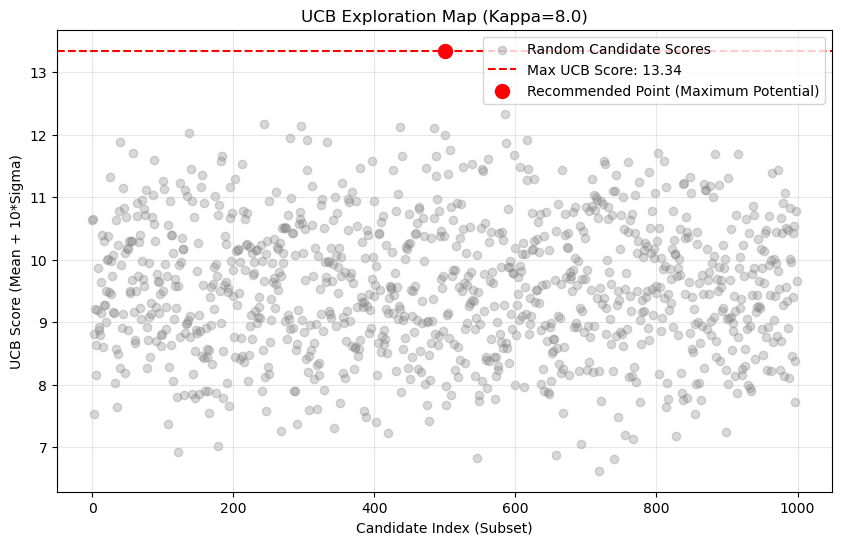

In [313]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs


# Updated input data including the new data from Week 1 and Week 2
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373])


# 2. Fit Gaussian Process with Matern kernel (robust for 8D)
# Matern 5/2 is less smooth than RBF, which is better for complex landscapes
kernel = C(1.0, (1e-3, 1e2)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30, alpha=1e-6)
gp.fit(X_train, y_train)

# 3. UCB Acquisition Function
def ucb_acquisition(gp, X, kappa=8.0):
    mean, sigma = gp.predict(X, return_std=True)
    return mean + kappa * sigma

# 4. Generate candidate points (Exploratory Sampling)
n_candidates = 250000 # set candidate points to 250000 to avoid curse of dimensionality
X_candidates = lhs(8, samples=n_candidates)

# 5. Evaluate candidates and find the next query
ucb_values = ucb_acquisition(gp, X_candidates, kappa=8.0)
next_idx = np.argmax(ucb_values)
next_query = X_candidates[next_idx]

# 6. Prediction for final verification
pred_mean, pred_std = gp.predict(next_query.reshape(1, -1), return_std=True)

print("--- Week 3 High-Exploration (UCB) ---")
print(f"Next Query Point (X):\n{next_query.tolist()}")
print(f"\nPredicted Mean: {pred_mean[0]:.4f}")
print(f"Uncertainty (Sigma): {pred_std[0]:.4f}")

# 7. Visualization: Plotting UCB Scores of Random Candidates vs Recommended
plt.figure(figsize=(10, 6))
# Plot a subset of candidates to show the distribution of potential
plt.scatter(range(1000), ucb_values[:1000], alpha=0.3, label='Random Candidate Scores', color='gray')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score: {np.max(ucb_values):.2f}')
plt.scatter([500], [np.max(ucb_values)], color='red', s=100, label='Recommended Point (Maximum Potential)')

plt.title('UCB Exploration Map (Kappa=8.0)')
plt.xlabel('Candidate Index (Subset)')
plt.ylabel('UCB Score (Mean + 10*Sigma)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()